# 03 · Engagement & Retention

**The question this notebook answers:** what does the path from registration to outcome look like as
a funnel, and how does retention (staying enrolled) evolve week by week — and does the
activation finding from notebook 02 hold up as a *time-series* story, not just a single-number
lift?

**Recap:** activation (≥3 active days in the first 14 days) predicts a 24.5-point success lift
(exposure-matched, per notebook 02's rigor-pass correction and independent verification — the
raw uncorrected figure is 34.8pp and overstates it) and, among the same 14-day-survivor
population, a 5.8-point drop in withdrawal (27.7pp unadjusted — most of that gap is the same
early-exit group counted twice, see notebook 02) — this notebook checks whether that shows up
consistently across the whole course, or only right at the start.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go

import prep
from viz_style import set_style, savefig, CATEGORICAL, STATUS, SEQUENTIAL_BLUE_ORDINAL, SURFACE, INK_PRIMARY

set_style()
pd.set_option("display.max_columns", 50)

raw = prep.load_raw()
enr = prep.load_processed("enrollments")
eng = prep.load_processed("engagement_14d")
act = prep.load_processed("activation")
assess = prep.load_processed("assessment_features")
weekly = prep.load_processed("weekly_activity")

MAX_WEEK = 33  # shortest course run is 234 days (~33.4 weeks) — capping here keeps every
               # course-run cohort observed for the full x-axis (no differential
               # censoring by course-run length). Weeks are 1-indexed (week 1 = days 0-6, the
               # first week) — see prep.to_display_week — so there's no week 0.

## The funnel

Five sequential (nested) stages: **registered → ever engaged with the platform → activated
(≥3 active days in the first 14 days) → submitted at least one assessment → success**. Each
stage requires every earlier stage too, so the counts can only shrink — this is what makes it a
funnel rather than five independent rates.


In [2]:
m = enr.merge(eng[prep.ENROLL_KEY + ["total_clicks"]], on=prep.ENROLL_KEY, how="left")
m["total_clicks"] = m["total_clicks"].fillna(0)
m = m.merge(act[prep.ENROLL_KEY + ["activated"]], on=prep.ENROLL_KEY, how="left")
m["activated"] = m["activated"].fillna(False)
m = m.merge(assess[prep.ENROLL_KEY + ["n_submissions"]], on=prep.ENROLL_KEY, how="left")
m["n_submissions"] = m["n_submissions"].fillna(0)

s1 = m["total_clicks"] > 0
s2 = s1 & m["activated"]
s3 = s2 & (m["n_submissions"] >= 1)
s4 = s3 & m["success"]

funnel = pd.Series(
    {"Registered": len(m), "Ever engaged": s1.sum(), "Activated": s2.sum(),
     "Submitted \u22651 assessment": s3.sum(), "Success": s4.sum()}
)
funnel_pct = funnel / funnel.iloc[0]
step_conv = funnel / funnel.shift(1)
step_conv.iloc[0] = 1.0

funnel_table = pd.DataFrame({"n": funnel, "pct_of_registered": funnel_pct, "step_conversion": step_conv})
funnel_table.round(3)


,n,pct_of_registered,step_conversion
Registered,32593,1.000,1.000
Ever engaged,29228,0.897,0.897
Activated,20094,0.617,0.687
Submitted ≥1 assessment,19071,0.585,0.949
Success,12162,0.373,0.638


In [3]:
fig = go.Figure(go.Funnel(
    y=funnel.index.tolist(),
    x=funnel.values.tolist(),
    textposition="inside",
    textinfo="label+value+percent initial+percent previous",
    marker={"color": SEQUENTIAL_BLUE_ORDINAL},
    connector={"line": {"color": "#c3c2b7", "width": 1}},
))
fig.update_layout(
    title="Registration-to-success funnel",
    paper_bgcolor=SURFACE,
    plot_bgcolor=SURFACE,
    font=dict(family="system-ui, -apple-system, sans-serif", color=INK_PRIMARY, size=13),
    margin=dict(l=140, r=40, t=60, b=20),
    width=760,
    height=440,
)
fig.write_image("images/03_funnel.png", scale=2)
fig.show()

**[OBS]** The steepest single-step drop is Registered → Ever engaged (89.7% step-conversion,
10.3% never click at all — the zero-engagement group from notebook 01), closely followed by
Ever engaged → Activated (68.7% step-conversion — under a third of engaged enrollments don't
reach 3 active days in the first 14). **[OBS]** The weakest step-conversion is Submitted →
Success (63.8%) — most of the people who get as far as submitting work don't necessarily fail
from disengagement, they fail on the work itself. **[OBS]** Submission is comparatively the
mildest filter (94.9% of activated enrollments go on to submit something) — once someone
activates, they very likely also submit; the two real bottlenecks are getting engaged at all,
and turning submitted work into a passing grade.


## Retention over time — does the gap between activated and not-activated widen or shrink across the term?

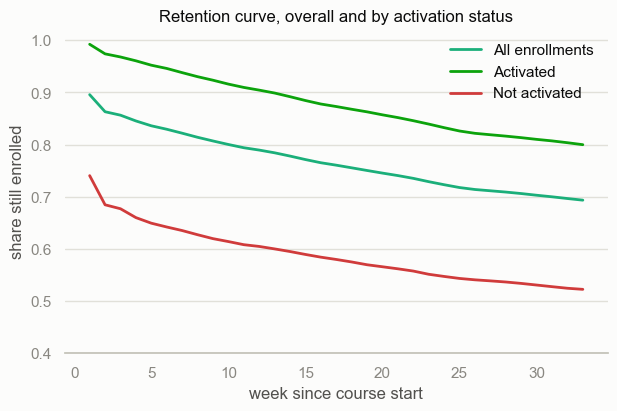

still enrolled at week 33: overall 69.3%, activated 80.0%, not activated 52.3%


In [4]:
enr_small = enr[prep.ENROLL_KEY + ["date_unregistration"]].merge(
    act[prep.ENROLL_KEY + ["activated"]], on=prep.ENROLL_KEY, how="left"
)
enr_small["activated"] = enr_small["activated"].fillna(False)

weeks = pd.DataFrame({"week": range(1, MAX_WEEK + 1)})  # week 1 = days 0-6, no week 0
grid = enr_small.merge(weeks, how="cross")
grid["still_enrolled"] = grid["date_unregistration"].isna() | (
    grid["date_unregistration"] >= grid["week"] * 7
)

overall = grid.groupby("week")["still_enrolled"].mean()
by_segment = grid.groupby(["week", "activated"])["still_enrolled"].mean().unstack()
by_segment.columns = ["Not activated", "Activated"]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(overall.index, overall.values, lw=2, color=CATEGORICAL[2], label="All enrollments")
ax.plot(by_segment.index, by_segment["Activated"], lw=2, color=STATUS["good"], label="Activated")
ax.plot(by_segment.index, by_segment["Not activated"], lw=2, color=STATUS["critical"], label="Not activated")
ax.set_xlabel("week since course start")
ax.set_ylabel("share still enrolled")
ax.set_title("Retention curve, overall and by activation status")
ax.set_ylim(0.4, 1.02)
ax.legend(frameon=False)
sns.despine(left=True)
savefig("03_retention_curve")
plt.show()

print(f"still enrolled at week {MAX_WEEK}: overall {overall.iloc[-1]:.1%}, "
      f"activated {by_segment['Activated'].iloc[-1]:.1%}, "
      f"not activated {by_segment['Not activated'].iloc[-1]:.1%}")


**[OBS]** The activated/not-activated gap opens immediately (99.2% vs. 74.1% still enrolled at
week 1 — many non-activated enrollments have already withdrawn before the course even starts)
and **widens further** through the term, ending at 80.0% vs. 52.3% by week 33. **This is a
consistency check on notebook 02's headline number**, not a new claim: 100% − 80.0% = 20.0% and
100% − 52.3% = 47.7% match notebook 02's 20.3%/48.0% withdrawal rates closely (the small gap is
the week-33 cutoff vs. whole-course withdrawal). The retention curve shows the gap widening
continuously across the whole term, not just appearing in a single end-of-course snapshot.

## When do withdrawals actually happen?

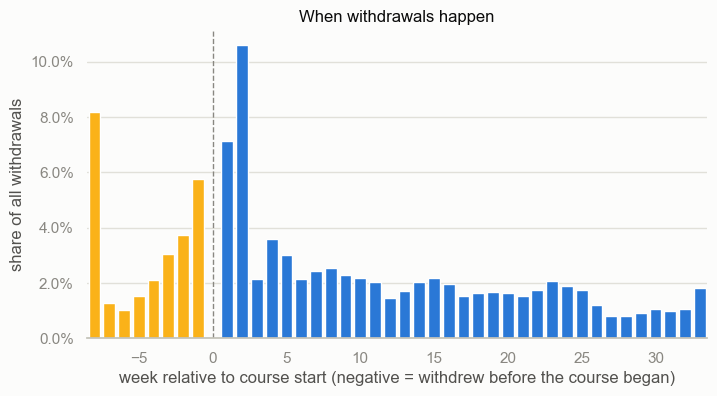

share of all withdrawals happening by week 2 (incl. pre-course): 44.3%


In [5]:
wk_withdraw = (
    enr.dropna(subset=["date_unregistration"])
    .assign(wk=lambda d: prep.to_display_week(d["date_unregistration"]).clip(lower=-8, upper=MAX_WEEK))
    .groupby("wk").size()
)
wk_withdraw_share = wk_withdraw / wk_withdraw.sum()

fig, ax = plt.subplots(figsize=(8, 4))
colors = [STATUS["warning"] if w < 0 else CATEGORICAL[0] for w in wk_withdraw_share.index]
ax.bar(wk_withdraw_share.index, wk_withdraw_share.values, color=colors, width=0.8)
ax.set_xlabel("week relative to course start (negative = withdrew before the course began)")
ax.set_ylabel("share of all withdrawals")
ax.set_title("When withdrawals happen")
ax.axvline(0, color="#898781", lw=1, ls="--")
ax.set_xlim(-8.5, MAX_WEEK + 0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
sns.despine(left=True)
savefig("03_withdrawal_timing")
plt.show()

early = wk_withdraw_share.loc[wk_withdraw_share.index <= 2].sum()
print(f"share of all withdrawals happening by week 2 (incl. pre-course): {early:.1%}")

**[OBS]** Withdrawal is front-loaded: 44.3% of all withdrawals happen by week 2 (i.e. within the
first two weeks of the course, plus anyone who dropped before it even started), including
a distinct pre-course group (negative weeks — 33.7% of all withdrawals happen before day 0)
who registered and then dropped before the course even started. **[HYP]** These look like two different phenomena worth different responses: a
pre-course/first-two-weeks "never really started" group (closest to a SaaS signup that never onboards),
and a smaller, steadier trickle of later withdrawals spread across the rest of the term (closer
to ongoing-engagement churn). A weak correlation with assessment due-dates was checked
(r≈0.1–0.27 depending on the week range used) and isn't reported as a finding — too unstable
across reasonable window choices to trust.


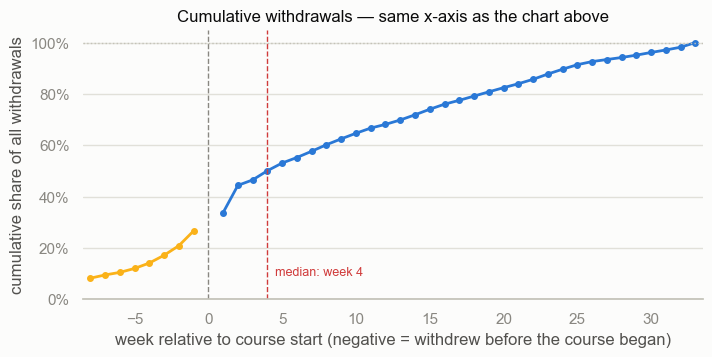

median withdrawal week: 4 (cumulative share = 50.0%)


In [6]:
cumulative = wk_withdraw_share.sort_index().cumsum()
pre = cumulative[cumulative.index < 0]
post = cumulative[cumulative.index >= 0]
median_week = cumulative[cumulative >= 0.5].index[0]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(pre.index, pre.values, color=STATUS["warning"], lw=2, marker="o", ms=4)
ax.plot(post.index, post.values, color=CATEGORICAL[0], lw=2, marker="o", ms=4)
ax.axvline(0, color="#898781", lw=1, ls="--")
ax.axhline(1.0, color="#c3c2b7", lw=1, ls=":")
ax.axvline(median_week, color=STATUS["critical"], lw=1, ls="--")
ax.text(median_week + 0.5, 0.08, f"median: week {median_week:.0f}",
        color=STATUS["critical"], fontsize=9, va="bottom")
ax.set_xlim(-8.5, MAX_WEEK + 0.5)
ax.set_ylim(0, 1.05)
ax.set_xlabel("week relative to course start (negative = withdrew before the course began)")
ax.set_ylabel("cumulative share of all withdrawals")
ax.set_title("Cumulative withdrawals — same x-axis as the chart above")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
sns.despine(left=True)
savefig("03_withdrawal_cumulative")
plt.show()

print(f"median withdrawal week: {median_week:.0f} (cumulative share = {cumulative[median_week]:.1%})")

## Engagement intensity over time

A different question from retention: among enrollments *still enrolled* in a given week, what share actually engage that week? Retention asks who's still there; this asks how active they are while there.

/var/folders/b4/_ns4q6653q1937kb0qj2zz300000gn/T/ipykernel_64921/1403698006.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grid2["active"] = grid2["active"].fillna(False)


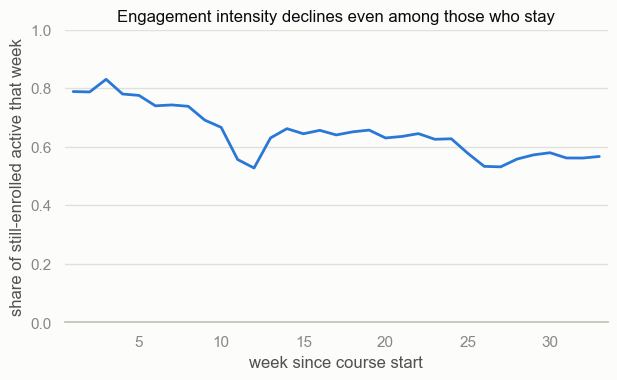

active rate: peak week 3 = 83.0%, week 33 = 56.7%


In [7]:
active_flags = (
    weekly[(weekly["week"].between(1, MAX_WEEK)) & (weekly["clicks"] > 0)]
    [prep.ENROLL_KEY + ["week"]]
    .assign(active=True)
)
grid2 = enr_small.merge(weeks, how="cross")
grid2["at_risk"] = grid2["date_unregistration"].isna() | (
    grid2["date_unregistration"] >= (grid2["week"] - 1) * 7
)
grid2 = grid2[grid2["at_risk"]].merge(active_flags, on=prep.ENROLL_KEY + ["week"], how="left")
grid2["active"] = grid2["active"].fillna(False)

active_rate = grid2.groupby("week")["active"].mean()

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(active_rate.index, active_rate.values, lw=2, color=CATEGORICAL[0])
ax.set_xlabel("week since course start")
ax.set_ylabel("share of still-enrolled active that week")
ax.set_title("Engagement intensity declines even among those who stay")
ax.set_xlim(0.5, MAX_WEEK + 0.5)
ax.set_ylim(0, 1)
sns.despine(left=True)
savefig("03_engagement_intensity")
plt.show()

peak_week = active_rate.idxmax()
print(f"active rate: peak week {peak_week} = {active_rate.max():.1%}, "
      f"week {MAX_WEEK} = {active_rate.loc[MAX_WEEK]:.1%}")

**[OBS]** Even among enrollments that remain enrolled, weekly active rate declines from a peak of
83.0% (week 3) to 56.7% by week 33, with two visible dips around weeks 11–12 and 26–27 — staying
enrolled and staying weekly-active are different things. **[HYP]** The two dips are plausibly
term breaks: most enrollments here start in October (`code_presentation` ending "J"), which
would put week 11–12 around mid/late December — a Christmas-break-shaped dip is a reasonable
guess, not a verified one, since semesters aren't separated out here. A fully
passive-but-not-withdrawn student can also show as "not active" for weeks without having
actually left — a genuine limitation of a clicks-based engagement measure with no "still reading
offline" signal.

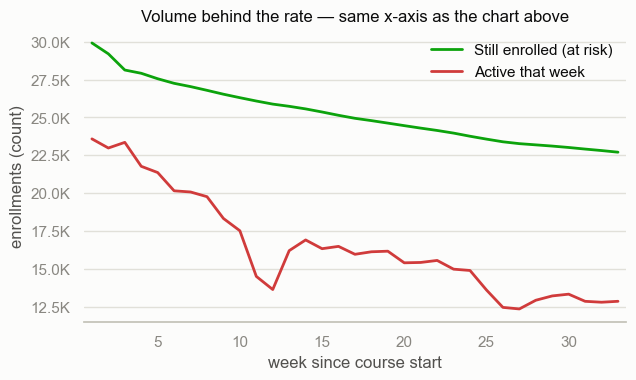

still enrolled: week 1 = 29,915, week 33 = 22,705 (24.1% decline)
active:         week 1 = 23,584, week 33 = 12,864 (45.5% decline)


In [8]:
volume = grid2.groupby("week").agg(still_enrolled=("active", "size"), active=("active", "sum"))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(volume.index, volume["still_enrolled"], lw=2, color=STATUS["good"], label="Still enrolled (at risk)")
ax.plot(volume.index, volume["active"], lw=2, color=STATUS["critical"], label="Active that week")
ax.set_xlabel("week since course start")
ax.set_ylabel("enrollments (count)")
ax.set_title("Volume behind the rate — same x-axis as the chart above")
ax.set_xlim(0.5, MAX_WEEK + 0.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K"))
ax.legend(frameon=False)
sns.despine(left=True)
savefig("03_engagement_volume")
plt.show()

still_start, still_end = volume["still_enrolled"].iloc[0], volume["still_enrolled"].iloc[-1]
active_start, active_end = volume["active"].iloc[0], volume["active"].iloc[-1]
print(f"still enrolled: week 1 = {still_start:,}, week {MAX_WEEK} = {still_end:,} "
      f"({1 - still_end/still_start:.1%} decline)")
print(f"active:         week 1 = {active_start:,}, week {MAX_WEEK} = {active_end:,} "
      f"({1 - active_end/active_start:.1%} decline)")

## Summary

**Observations / Hypothesis / Conclusion, tagged:**
- **[OBS]** Funnel: 100% → 89.7% (ever engaged) → 61.7% (activated) → 58.5% (submitted
  \u22651) → 37.3% (success). The two real bottlenecks are the first step (never engaging)
  and getting engaged enough to activate; submission-to-success is the weakest step-conversion
  but is an academic-performance gap, not an engagement gap.
- **[CON]** The activation effect from notebook 02 is not a single end-of-course artifact — the
  retention curve shows the gap open immediately and widen steadily across the whole term, and
  the week-33 numbers reproduce notebook 02's totals as a consistency check.
- **[OBS]** Withdrawal is front-loaded: a large share happens by week 2 (including a
  pre-course-withdrawal group), with a steadier, smaller trickle afterward — two different
  churn phenomena, plausibly calling for two different interventions.
- **[OBS]** Weekly engagement intensity declines even among students who remain enrolled —
  retention and activity are related but distinct measures.

**Concepts used (added running list):** funnel as nested AND-conditions (not independent
marginal rates), survival/retention-curve construction with a shared observation-window cutoff
to avoid differential censoring, engagement-intensity vs. retention as distinct constructs,
a weak/unstable correlation explicitly not reported as a finding.

---
**Next:** `04_Feature_Adoption_and_Segmentation.ipynb` — which platform features (VLE activity
types) get used, by whom, and whether adoption mix (not just volume) relates to outcome.
